### 加载数据

In [3]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skfolio import Population,MultiPeriodPortfolio
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
from log_result import init_logger, log_result, log_print
set_config(transform_output="pandas")
init_logger("Simulation_252")      # 只调用一次, 绑定文件名
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 关键: 负号才不会变方块

[log] 已绑定: D:\machine-learning-for-trading\case_studies\lazy_trading\logs\Simulation_252.log


In [2]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
print(f"资产池: {len(all_symbols)} 只 | {len(prices)} 天 | {prices.index[0].date()} ~ {prices.index[-1].date()}")

# 市场基准（从资产池中取出）
bench_symbol = "510300.SH"
bench = prices[bench_symbol]
prices = prices.drop(columns=[bench_symbol])

# 双口径收益率: X=绝对收益, X_net=超额收益(减基准), 筛选与训练统一用X_net
X = prices_to_returns(prices, drop_inceptions_nan=False)
bench_ret = prices_to_returns(bench.to_frame("bench"), drop_inceptions_nan=False)["bench"]
X_net = X.sub(bench_ret, axis=0)

# Inf 检查（两口径分别报告）
for label, df in [("X", X), ("X_net", X_net)]:
    inf = df.columns[np.isinf(df).any(axis=0)]
    print(f"{label} Inf列 {len(inf)}" + (f" -> {inf.tolist()}" if len(inf) else ""))

# 异常收益检查: 以超额口径判定, 同步剔除, 保证两口径列集一致
bad = X_net.columns[(X_net.abs() > 0.25).any()]
X = X.drop(columns=bad)
X_net = X_net.drop(columns=bad)
msg = f"异常剔除(±25%): {len(bad)} 列 -> {bad.tolist()}" if len(bad) else "异常剔除(±25%): 0 列"
print(msg)
print(f"清洗后: {X.shape[0]} 天 x {X.shape[1]} 资产 | 列集一致: {list(X.columns) == list(X_net.columns)}")

资产池: 2116 只 | 2579 天 | 2016-01-04 ~ 2026-08-14
X Inf列 0
X_net Inf列 0
异常剔除(±25%): 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']
清洗后: 2578 天 x 2112 资产 | 列集一致: True


### 参数搜索
- Walkforward:
    - CombinatorialPurgedCV

In [4]:
from wf_cpcv_search import load_nested_config
from cpcv_search_base import build_pipeline_src
from walkforward_parameter_search import compute_grid_size
from wf_cpcv_search import nested_adaptive_search, adaptive_multi_paths, build_test_parts, summarize_fold_params,summarize_top_k_params
from cpcv_analysis import discrete_lhs_safe, diagnose_oos_lhs, report_ann_distribution, turnover_series
from cpcv_analysis import plot_oos_vs_bench,excess_vs_bench, plot_paths_curve
from wf_cpcv_robustness import (perturbation_mc, sensitivity_curves, sensitivity_heatmap, topk_paths_eval,)
from wf_cpcv_ablation import ablate

In [5]:
log_print("mean(Annualized Sharpe Ratio)/2 - mean(MAXDD) + mean(SKEW)", section='Ojective', echo=False)
log_print(build_pipeline_src(), section="Model Pipeline", echo=False)

In [6]:
search_space = {'nondomin__min_n_assets': {'low': 5, 'high': 55, 'step': 5},
 'nondomin__threshold': {'low': -0.5, 'high': -0.3, 'step': 0.1},
 'correlate__threshold': {'low': 0.1, 'high': 0.5, 'step': 0.1},
 'extremes__k': {'low': 0.1, 'high': 0.6, 'step': 0.1},
 'nondomin__fitness_measures': [
    "mean-variance-kurt",
    "mean-variance-maxdd-kurt",
    "mean-variance-avgdd-kurt",
    "mean-semideviation-avgdd",
    "mean-mad-maxdd-kurt",
    "mean-mad-avgdd-kurt",
    "mean-mad-maxdd-cvar-kurt",
    "mean-mad-maxdd-cvar-sharpe",
    "mean-mad-avgdd-cvar-kurt",
    "mean-mad-avgdd-cvar-sharpe",
    ],
 'train_size': {'low': 252, 'high': 756, 'step': 126}}  # inner train size
log_print(search_space, section='Parameter Space', echo=False)
compute_grid_size(search_space)

49500

In [73]:
search_params = {'test_size': 126,
  'train_size': 756+126,
  'n_test_folds': 2,
  'n_jobs': 4,
  'cv_n_jobs': 8,
  'n_trials': 2000,
  'patience': 50,
  'sampler': 'tpe',
  'min_delta': 0.0001,
  'outer_purged_size': 0,
  'outer_reduce_test': False,
  'seed': 42,
  'verbose': True}
log_print(search_params, section="Search Parameter", echo=False)

In [74]:
fold_results = nested_adaptive_search(X,space=search_space, **search_params)

  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 0: mean score=0.7718 | test_ann=0.2785 | test_days=126


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 1: mean score=1.2712 | test_ann=-0.0371 | test_days=126


  0%|          | 0/2000 [00:00<?, ?it/s]

...

Fold 10: mean score=1.3969 | test_ann=0.0956 | test_days=126


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 11: mean score=0.5641 | test_ann=0.3206 | test_days=126


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 12: mean score=1.3419 | test_ann=0.1896 | test_days=126


### Step 1 | IS 审计：每折 P Luck + Top-K 候选
- dsr = 该折最优分数超过"纯运气挑最优"基准的经验概率（H0 噪声 MC deflate，N = 参数去重后的真实试验数）。 margin = sr_obs − E[max_N]，max_p95 为运气基准 95% 分位。
- gap2top1（summarize_top_k_params 的列）= IS 侧 top1 与 top2 的分数落差： 落差小 → 参数处在平台（好信号）；落差大 → top1 可能是运气孤峰（坏信号）。

In [75]:
log_print(summarize_fold_params(fold_results).to_string(),section='Best Parameter', echo=True)

    fold   score  p_luck  margin  train ASR  test ASR  nondomin__min_n_assets  nondomin__threshold  correlate__threshold  extremes__k  train_size                     fitness  n_trials
0      0  0.7718  0.7983 -0.1079     1.1187    3.1573                      40                 -0.4                   0.1          0.6         252         mean-mad-avgdd-kurt        63
1      1  1.2712  0.4967 -0.0104     1.4102   -0.4142                      55                 -0.5                   0.1          0.6         252          mean-variance-kurt        77
2      2  1.0158  0.8733 -0.1851     3.0285    0.8096                      55                 -0.5                   0.3          0.4         252  mean-mad-avgdd-cvar-sharpe        79
3      3  1.4183  0.8807 -0.2648     2.0206    5.0830                      20                 -0.3                   0.2          0.4         252         mean-mad-maxdd-kurt        80
4      4  1.7328  0.4736 -0.0172     0.7086    0.5873                       5   

In [76]:
topk = summarize_top_k_params(fold_results, k=5)         # 行 = (fold, rank)
print(topk[topk["rank"] <= 3][['fold','rank','score','gap2top1']])                    # 每折 top1/top2 候选 + gap2top1

    fold  rank   score  gap2top1
0      0     1  0.7718    0.0000
1      0     2  0.7160    0.0558
2      0     3  0.7160    0.0558
5      1     1  1.2712    0.0000
6      1     2  1.1927    0.0785
7      1     3  1.1339    0.1373
10     2     1  1.0158    0.0000
11     2     2  1.0012    0.0146
12     2     3  0.9676    0.0482
15     3     1  1.4183    0.0000
16     3     2  1.4175    0.0008
17     3     3  1.4175    0.0008
20     4     1  1.7328    0.0000
21     4     2  1.5805    0.1523
22     4     3  1.3494    0.3834
25     5     1  1.2032    0.0000
26     5     2  1.0401    0.1630
27     5     3  1.0198    0.1834
30     6     1  0.4880    0.0000
31     6     2  0.4704    0.0176
32     6     3  0.4559    0.0321
35     7     1  0.6260    0.0000
36     7     2  0.6260    0.0000
37     7     3  0.6260    0.0000
40     8     1  0.5831    0.0000
41     8     2  0.5741    0.0090
42     8     3  0.5335    0.0496
45     9     1  1.2043    0.0000
46     9     2  1.2015    0.0029
47     9  

### Step 2｜过拟合判据：DSR 低 + OOS 衰减
- 判据：WFE > 0.5 为稳健泛化（多数折满足）。
- "DSR 低 + OOS 显著下降" = 内层选择偏差校正后无真实优势 + 样本外掉队 → 该折结论不可信，

In [77]:
df = summarize_fold_params(fold_results).copy()
df["WFE"] = df["test ASR"] / df["train ASR"]      # 每折 IS→OOS 衰减比
df["flag"] = (df["p_luck"] > 0.5) & (df["WFE"] < 0.5)   # 运气嫌疑高 + 衰减 = 过拟合嫌疑折
print(df[["fold", "p_luck", "train ASR", "test ASR", "WFE", "flag"]])

    fold  p_luck  train ASR  test ASR       WFE   flag
0      0  0.7983     1.1187    3.1573  2.822294  False
1      1  0.4967     1.4102   -0.4142 -0.293717  False
2      2  0.8733     3.0285    0.8096  0.267327   True
3      3  0.8807     2.0206    5.0830  2.515589  False
4      4  0.4736     0.7086    0.5873  0.828817  False
5      5  0.3504     0.5599   -0.5705 -1.018932  False
6      6  0.4568     1.1560    1.8407  1.592301  False
7      7  0.8492     0.4841    1.1400  2.354885  False
8      8  0.4187     1.0304    1.9111  1.854717  False
9      9  0.6984     1.0080    0.9151  0.907837  False
10    10  0.7622     1.4363    0.9971  0.694214  False
11    11  0.4998     1.4428    4.4207  3.063973  False
12    12  0.5372     1.0997    1.9139  1.740384  False


### Step 3｜Top-K 候选 OOS 多路径压测
- 窗口自动从 folds 推导（折位 1:1）；如需 notebook 原压测口径（如 `n_test_folds=4`），
  以显式键传入：`topk_paths_eval(X, folds, paths_kwargs={"n_test_folds": 4})`。
- 价值在**参数高原的 OOS 侧印证**：gap2top1 小的候选若 OOS 同样接近，说明生产参数处在稳定平台。

In [78]:
eval_ = topk_paths_eval(X, fold_results, k=10)            # 每折 top1~5 全部进 CPCV 多路径压测

rank1: 完整OOS路径 | 13 折拼接 | 1638 天
rank2: 完整OOS路径 | 13 折拼接 | 1638 天
rank3: 完整OOS路径 | 13 折拼接 | 1638 天
rank4: 完整OOS路径 | 13 折拼接 | 1638 天
rank5: 完整OOS路径 | 13 折拼接 | 1638 天
rank6: 完整OOS路径 | 13 折拼接 | 1638 天
rank7: 完整OOS路径 | 13 折拼接 | 1638 天
rank8: 完整OOS路径 | 13 折拼接 | 1638 天
rank9: 完整OOS路径 | 13 折拼接 | 1638 天
rank10: 完整OOS路径 | 13 折拼接 | 1638 天


In [79]:

paths = eval_["paths"]                            # MultiIndex (fold, rank, path)
audit = eval_["audit"]                            # IS 侧审计，与 paths 按 (fold, rank) 对齐
sharpe = paths["annualized_sharpe_ratio"].groupby("rank").mean()
print(sharpe)              # rank 均值对比（不选参，只看高原）

rank
1     1.279601
2     1.272499
3     1.492496
4     0.772002
5     1.325899
6     1.319230
7     1.183574
8     1.550520
9     1.420601
10    1.290083
Name: annualized_sharpe_ratio, dtype: float64


In [80]:
log_print(paths, section="Top 10 参数组合OOS:ASR,MEAN,MAXDD")

      annualized_sharpe_ratio  annualized_mean  max_drawdown
rank                                                        
1                    1.279601         0.110166      0.114594
2                    1.272499         0.109687      0.103901
3                    1.492496         0.126947      0.131338
4                    0.772002         0.061573      0.188325
5                    1.325899         0.105481      0.089545
6                    1.319230         0.118860      0.126849
7                    1.183574         0.107912      0.126849
8                    1.550520         0.133928      0.147126
9                    1.420601         0.132266      0.110106
10                   1.290083         0.119590      0.124461


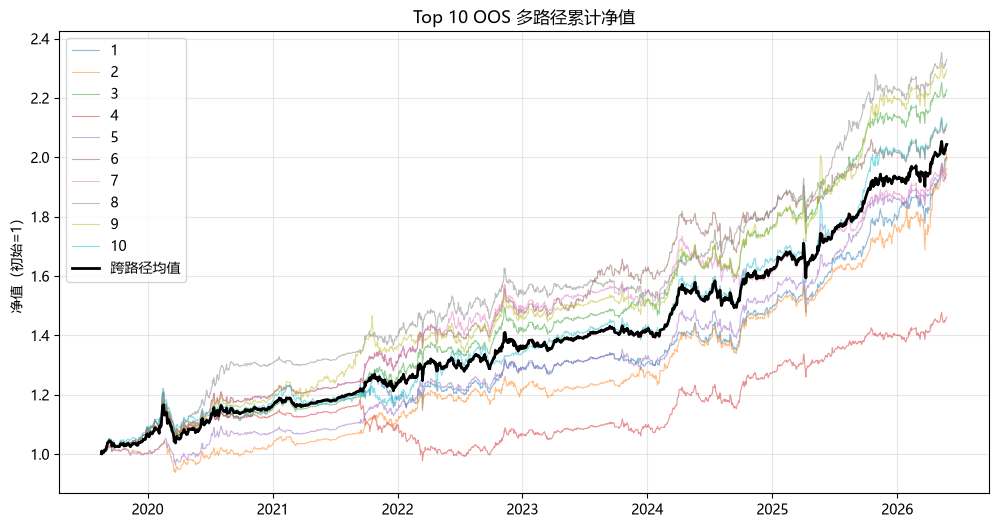

In [81]:
top_k_mpts = Population([mpt for mpt in eval_['mpts'].values()])
plot_paths_curve(top_k_mpts, title='Top 10 OOS 多路径累计净值', labels=[k for k in eval_['mpts'].keys()])

### Ensemble

In [16]:
from wf_topk_ensemble import topk_ensemble_eval

In [82]:
ens = topk_ensemble_eval(X, fold_results, k=10) 

Fold 0: 候选=10 | top1资产=6 | 融合池=8（重叠=6）| top1_test=3.1573 | ens_test=3.6633
Fold 1: 候选=10 | top1资产=7 | 融合池=13（重叠=7）| top1_test=-0.4142 | ens_test=1.4921
Fold 2: 候选=10 | top1资产=17 | 融合池=24（重叠=17）| top1_test=0.8096 | ens_test=0.6933
Fold 3: 候选=10 | top1资产=3 | 融合池=8（重叠=3）| top1_test=5.0830 | ens_test=1.8935
Fold 4: 候选=10 | top1资产=3 | 融合池=12（重叠=3）| top1_test=0.5873 | ens_test=0.2964
Fold 5: 候选=10 | top1资产=4 | 融合池=11（重叠=4）| top1_test=-0.5705 | ens_test=-0.0309
Fold 6: 候选=10 | top1资产=6 | 融合池=7（重叠=6）| top1_test=1.8407 | ens_test=0.9623
Fold 7: 候选=10 | top1资产=3 | 融合池=6（重叠=3）| top1_test=1.1400 | ens_test=1.5723
Fold 8: 候选=10 | top1资产=7 | 融合池=9（重叠=7）| top1_test=1.9111 | ens_test=1.4301
Fold 9: 候选=10 | top1资产=5 | 融合池=10（重叠=5）| top1_test=0.9151 | ens_test=1.0005
Fold 10: 候选=10 | top1资产=13 | 融合池=19（重叠=13）| top1_test=0.9971 | ens_test=0.8381
Fold 11: 候选=10 | top1资产=4 | 融合池=13（重叠=4）| top1_test=4.4207 | ens_test=4.3702
Fold 12: 候选=10 | top1资产=13 | 融合池=19（重叠=13）| top1_test=1.9139 | ens_test=1.9276
完整 OO

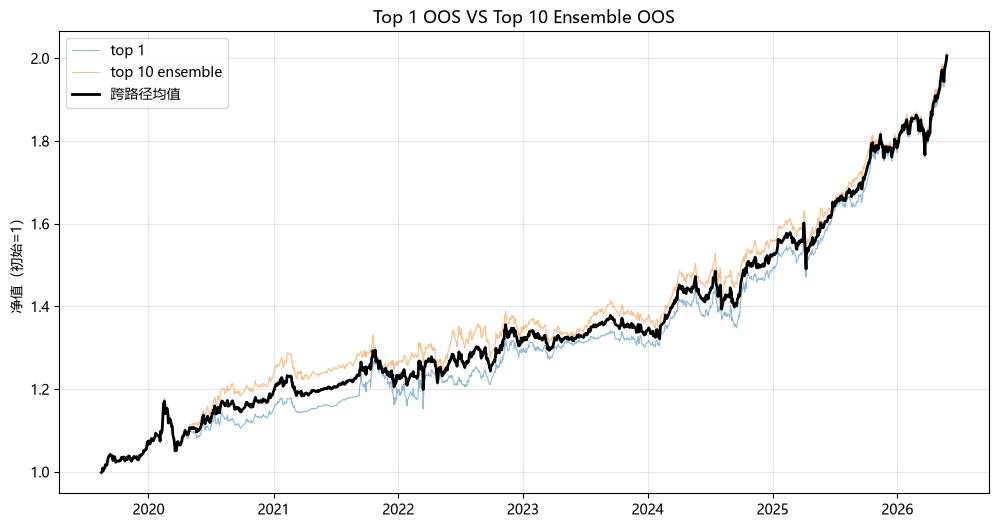

In [83]:
ensemble_mpt = Population([ens['paths']['top1'], ens['paths']['ensemble']])
plot_paths_curve(ensemble_mpt, title='Top 1 OOS VS Top 10 Ensemble OOS', labels=['top 1','top 10 ensemble'])

In [19]:
log_print(ens['paths']['ensemble'].summary(),section='Top 5 Ensemble OSS Summary',echo=False)

### Step 4｜单参数敏感性曲线
- 每折只动目标参数、其余保持生产值（fitness 固定 top1）；`frac=0` 档即生产值本身（锚点）。
- 默认覆盖**全部数值参数含 `train_size`**（它是搜索维度之一，扰动后评估即用扰动后的拟合窗口长度）。
- 读图：参数高原 = ±30% 内绩效平缓；孤峰 = 仅生产值附近突出（与 IS 侧 gap2top1 互证）。
- 只评估单折 OOS → 无 CPCV 展开，成本低，可全参数全档位跑。

In [16]:
curves = sensitivity_curves(X, fold_results, reduce_test=False)             # 默认 ±10/20/30% 六档 × 全部数值参数
c = curves[curves["param"] == "extremes__k"]
ax = c.pivot_table(index="frac", columns="fold",
                   values="annualized_sharpe_ratio").plot(marker="o")

Fold 0: 单参网格完成 (5 参数 × 6 档)
Fold 1: 单参网格完成 (5 参数 × 6 档)
Fold 2: 单参网格完成 (5 参数 × 6 档)
Fold 3: 单参网格完成 (5 参数 × 6 档)
Fold 4: 单参网格完成 (5 参数 × 6 档)
Fold 5: 单参网格完成 (5 参数 × 6 档)
Fold 6: 单参网格完成 (5 参数 × 6 档)
Fold 7: 单参网格完成 (5 参数 × 6 档)
Fold 8: 单参网格完成 (5 参数 × 6 档)
Fold 9: 单参网格完成 (5 参数 × 6 档)
Fold 10: 单参网格完成 (5 参数 × 6 档)
Fold 11: 单参网格完成 (5 参数 × 6 档)
Fold 12: 单参网格完成 (5 参数 × 6 档)


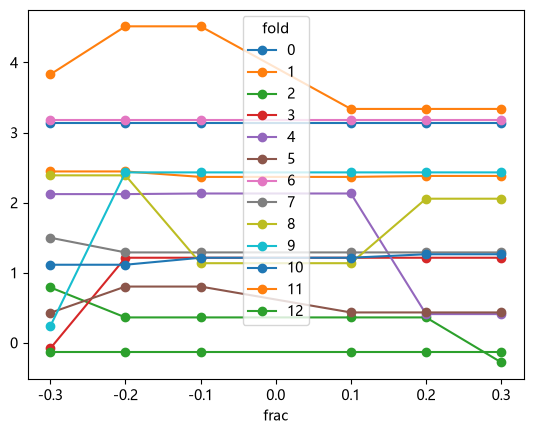

In [17]:
plt.show()

### Step 5｜双参数联合热力图（checklist 4.2）

- 返回 `{fold: DataFrame(index=frac_a, columns=frac_b), "mean": 跨折逐格平均}`。
- 读图：各档平缓 → 联合高原（稳健）；仅 (0,0) 突出 → 联合孤峰（脆弱）；
  对角陡峭 → 两参数互补/冲突（交互项存在）。

Fold 0: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 1: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 2: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 3: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 4: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 5: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 6: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 7: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 8: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 9: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 10: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 11: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 12: extremes__k×correlate__threshold 热力图 (5×5) 完成


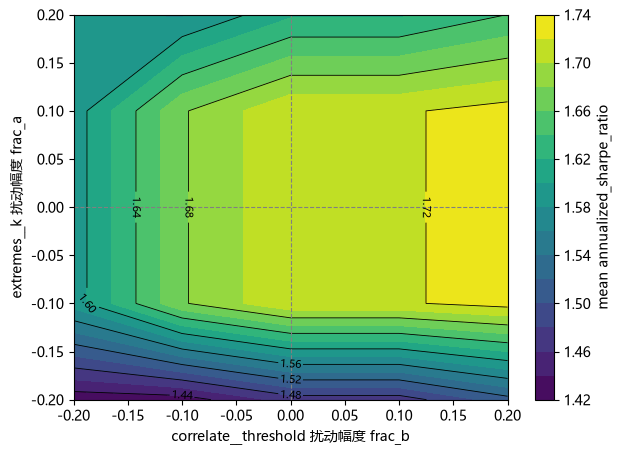

In [84]:
import numpy as np
import matplotlib.pyplot as plt

grids = sensitivity_heatmap(X, fold_results, param_a="extremes__k",
                            param_b="correlate__threshold",
                            reduce_test=False)
mean = grids["mean"]                          # 行=frac_a, 列=frac_b, 值=跨折平均ASR
Xg, Yg = np.meshgrid(mean.columns, mean.index)   # x=frac_b, y=frac_a，与 values[i,j] 对齐
fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(Xg, Yg, mean.values, levels=15, cmap="viridis")   # 彩色填充
cs = ax.contour(Xg, Yg, mean.values, levels=8, colors="k", linewidths=0.6)  # 等值线
ax.clabel(cs, inline=True, fontsize=8)        # 标数值
ax.axhline(0, color="gray", lw=0.8, ls="--")  # 生产值锚点十字线（0,0 = 未扰动）
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("correlate__threshold 扰动幅度 frac_b")
ax.set_ylabel("extremes__k 扰动幅度 frac_a")
fig.colorbar(cf, label="mean annualized_sharpe_ratio")
plt.show()

### Step 6｜消融实验

- 臂：`full`（基准）/ `no_extremes` / `no_nondomin` / `no_correlate` / `no_extremes_correlate`。
- 每臂 = 固定每折最优参数 × 剔除对应管线步骤 × CPCV 多路径压测（同窗同口径对比）。
- 判读：全臂样本路径数一致（每折 = `n_test_folds` 组合路径），绩效差距即模块边际贡献；
  某模块剔除后绩效**不降反升** → 该模块负贡献，考虑剔除后重搜（会作废旧 OOS）。

In [85]:
frames, summary = ablate(X, fold_results)                # arms=None = 全部 5 臂
summary

,说明,折数,天数,annualized_mean,annualized_sharpe_ratio,max_drawdown,skew,kurtosis
臂,,,,,,,,
full,全管线（基准）,13,1638,0.110166,1.279601,0.114594,-0.169374,10.017376
no_extremes,无峰度预筛（剔除 extremes 步骤）,13,1638,0.087476,1.329100,0.080263,-0.319975,14.706099
no_nondomin,无非支配筛选（剔除 nondomin 步骤）,13,1638,0.140149,1.430629,0.107058,-0.706178,11.206176
no_correlate,无去相关（剔除 correlate 步骤）,13,1638,0.094239,0.682438,0.332890,-0.812192,9.530439
no_extremes_correlate,剔除 extremes + correlate,13,1638,0.101051,1.011182,0.166716,-0.623899,7.256909


In [24]:
log_result(summary.to_string(), section="消融实验")

### Step 7｜参数扰动蒙特卡洛 + 判定

In [ ]:
out = perturbation_mc(X, fold_results, fitness_topk=5)                   # R=None → ceil(500 / 折数)，总样本 ≥ 500

In [150]:
out['verdict']

,指标,样本数,prob>0,median,p95,通过
0,annualized_mean,507,0.903353,0.113004,0.316511,True
1,annualized_sharpe_ratio,507,0.903353,1.261678,3.139579,True


In [151]:
out['fold_summary']

,n,annualized_mean_mean,annualized_mean_median,annualized_mean_p5,annualized_mean_p95,annualized_sharpe_ratio_mean,annualized_sharpe_ratio_median,annualized_sharpe_ratio_p5,annualized_sharpe_ratio_p95,max_drawdown_mean,...,max_drawdown_p95,skew_mean,skew_median,skew_p5,skew_p95,kurtosis_mean,kurtosis_median,kurtosis_p5,kurtosis_p95,pos_prob
fold,,,,,,,,,,,,,,,,,,,,,
0,39,0.114112,0.052112,0.017740,0.396740,1.292467,1.046858,0.295861,3.139579,0.036794,...,0.054353,0.035468,0.242569,-0.726920,0.553630,6.161362,6.350444,5.386924,6.641066,1.000000
1,39,0.195789,0.211091,0.090474,0.288069,1.883484,1.904748,1.071884,2.735408,0.065966,...,0.084900,-0.212261,-0.253512,-0.449060,0.269177,4.041860,3.945983,3.697458,4.810543,0.974359
2,39,0.046928,0.042260,0.002194,0.167671,0.880226,0.738002,0.043091,2.021897,0.032544,...,0.070278,-0.176149,-0.204486,-0.502634,0.371917,4.022140,3.236600,2.566316,6.451092,0.948718
3,39,0.105298,0.113004,-0.021499,0.206258,2.029180,2.520180,-0.315142,3.648628,0.027009,...,0.062454,0.002319,0.097402,-0.371923,0.344133,5.147773,5.029438,3.082278,6.901054,0.923077
4,39,0.150439,0.274079,-0.265825,0.274087,1.184110,2.121271,-1.994514,2.130047,0.071298,...,0.188325,-0.114541,-0.094199,-0.508079,0.224505,4.287416,3.650374,3.082842,5.414486,0.820513
5,39,0.034034,0.035678,-0.043088,0.084941,0.278861,0.333539,-0.397490,0.676169,0.071297,...,0.086521,-0.426293,-0.505634,-0.744690,0.010939,4.645636,4.594550,3.328906,6.006268,0.846154
6,39,0.128697,0.127023,0.112960,0.159354,1.983736,1.667762,0.961118,3.177725,0.058187,...,0.106783,0.376001,0.392628,0.024525,0.494194,4.841346,5.233428,3.567264,5.620750,1.000000
7,39,0.068929,0.057047,-0.025251,0.131066,1.147436,1.190865,-0.480029,2.247332,0.033492,...,0.043910,-0.035558,0.031480,-0.280501,0.210641,3.895007,3.235186,2.608128,5.161216,0.871795
8,39,0.129383,0.136881,-0.003978,0.305578,1.874885,1.661872,-0.029823,3.241179,0.057772,...,0.126369,0.302549,0.516515,-0.173364,0.714591,5.078777,5.892025,2.591490,7.214605,0.820513


In [86]:
oos_pop = Population([fold['test'] for fold in fold_results])
oos_pop.plot_cumulative_returns()

In [87]:
oos_mpt = MultiPeriodPortfolio([fold['test'] for fold in fold_results],compounded=True)
oos_mpt.plot_cumulative_returns()

#### 路径采样

In [88]:
fold_paths = adaptive_multi_paths(X, fold_results, 
                                 test_size=search_params['test_size'], 
                                 train_size=search_params['train_size'],
                                 n_test_folds=search_params['n_test_folds'], n_jobs=8)

Fold 0: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 1: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 2: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 3: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 4: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 5: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 6: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 7: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 8: paths=13 | window=882 | inner_folds=14 | test_days=126
Fold 9: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 10: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 11: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 12: paths=11 | window=756 | inner_folds=12 | test_days=126


In [89]:
oos_blocks = build_test_parts(fold_paths, n_test_folds=search_params['n_test_folds'])
oos_paths = discrete_lhs_safe(oos_blocks, n_samples=1000, seed=42)
oos_mpts = Population([MultiPeriodPortfolio(path ,compounded=False) for path in oos_paths])

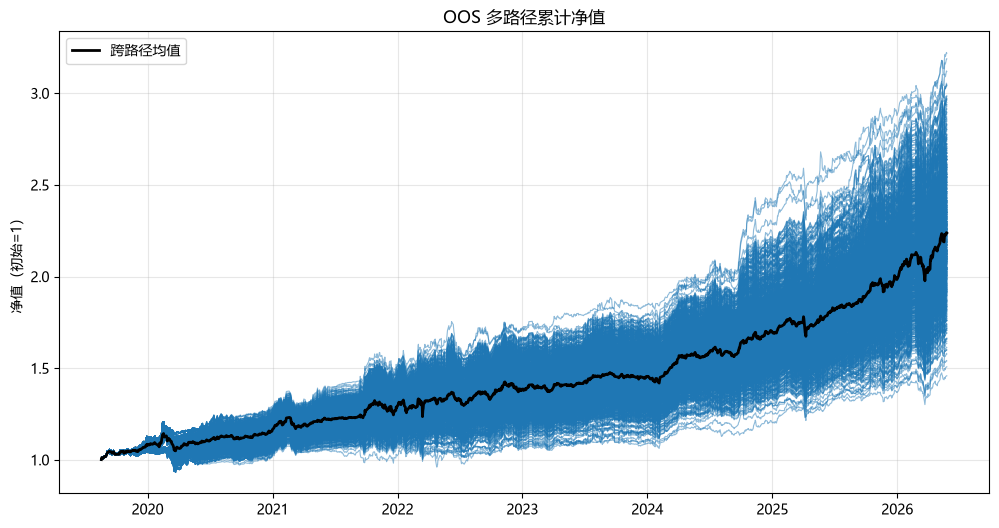

In [90]:
plot_paths_curve(oos_mpts)

In [31]:
log_print(oos_mpt.summary(),section='OSS Summary',echo=False)

### OOS诊断：
- Annualized Mean 分布
- PSR诊断
- 基准联动
- 换手频率

LHS多路径分布(1000条): 均值 0.1272 | 中位 0.1273 | 5% 0.0954 | 95% 0.1590
WF真实路径: 0.1089 | 分布中 -0.94σ | 分位 16.9%


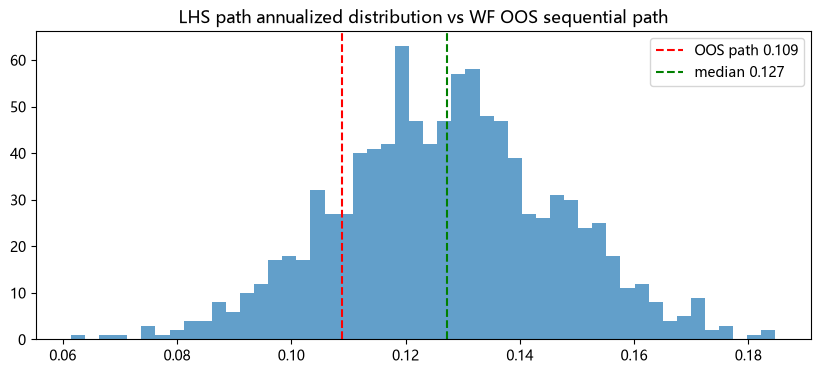

In [91]:
# 年化分布
path_anns = np.array([oos_mpt.annualized_mean for oos_mpt in oos_mpts])

oos_ann = oos_mpt.annualized_mean

report_ann_distribution(path_anns, oos_ann)

In [92]:
diagnose_result = diagnose_oos_lhs(lhs_paths=oos_paths)
del diagnose_result['mc_sharpes']
del diagnose_result['mc_mdds']
del diagnose_result['mc_psrs']
log_print(diagnose_result, section='OOS PSR Diagnose',echo=False)

[Info] 1000 LHS paths | OOS 1638 days

          纯 OOS 策略诊断报告 (LHS)
  ✅ P(SR<=0)              : 0.00%
  ✅ Sharpe 90% CI         : [0.840, 1.433]
  ✅ MDD median / worst-5%  : 10.33% / 15.80%
------------------------------------------------------------
  ⚠️ SR_obs (median)       : 1.1443
  ⚠️ PSR(0) median / 5%    : 100.00% / 100.00%


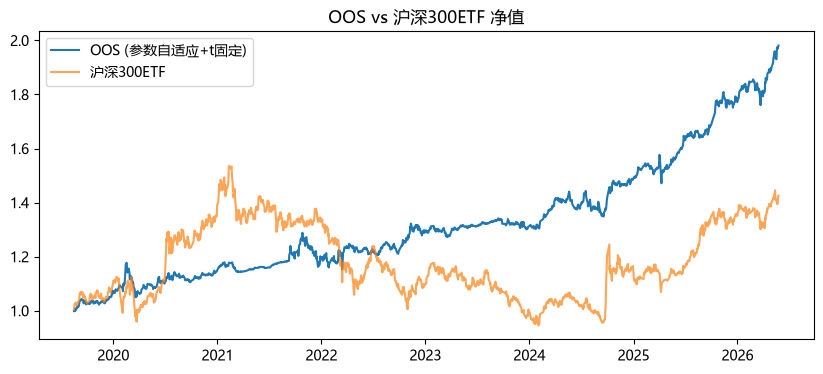

In [93]:
plot_oos_vs_bench(oos_mpt, bench_ret)

In [94]:

df_ex = excess_vs_bench(oos_mpts, bench_ret)
log_result(df_ex.describe(percentiles=[0.05, 0.5, 0.95]).loc[["5%", "50%", "95%", "mean"]].round(4),
           section="OOS vs 沪深300 相对收益分布")

      ann_excess  arith_excess      IR  winrate
5%        0.0369        0.0268  0.1767   0.5165
50%       0.0671        0.0587  0.3801   0.5281
95%       0.0971        0.0904  0.5860   0.5385
mean      0.0670        0.0586  0.3807   0.5275


### Simulation

In [36]:
from sl_simulation import load_sl_config, simulate_sl, summarize_sl

In [95]:
cfg  = load_sl_config()
cfg['space'] = search_space
cfg['search_kwargs'] = search_params

In [ ]:

cfg['stop_loss'] = {'min_epoch_days': 0,
    'conditions': [{
        'name': 'epoch_dd',
        'metric': 'drawdown',
        'op': '<=',
        'threshold': -0.10}]}

In [96]:
base = simulate_sl(X, folds=fold_results, cfg=cfg)

Epoch 0: 2019-08-16 -> 2020-02-26 (126d, expired) | src=fold_reuse | ASR=3.157 | 累计=14.71%
Epoch 1: 2020-02-27 -> 2020-03-19 (16d, sl:epoch_cumloss) | src=fold_reuse | ASR=-12.172 | 累计=-8.49%
决策日 2020-03-19: fresh CPCV 重搜 | 外层窗口 882 天 | test_size=126 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 2: 2020-03-20 -> 2020-09-21 (126d, expired) | src=fresh | ASR=2.851 | 累计=14.53%
决策日 2020-09-21: fresh CPCV 重搜 | 外层窗口 882 天 | test_size=126 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 3: 2020-09-22 -> 2021-04-01 (126d, expired) | src=fresh | ASR=-0.230 | 累计=-1.04%
决策日 2021-04-01: fresh CPCV 重搜 | 外层窗口 882 天 | test_size=126 | n_trials=2000


...

Epoch 4: 2021-04-02 -> 2021-10-12 (126d, expired) | src=fresh | ASR=1.494 | 累计=6.64%
决策日 2021-10-12: fresh CPCV 重搜 | 外层窗口 882 天 | test_size=126 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 5: 2021-10-13 -> 2022-04-18 (126d, expired) | src=fresh | ASR=1.151 | 累计=8.18%
决策日 2022-04-18: fresh CPCV 重搜 | 外层窗口 882 天 | test_size=126 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [69]:
res  = simulate_sl(X, cfg=cfg)

决策日 2020-02-26: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 0: 2020-02-27 -> 2020-03-16 (13d, sl:epoch_cumloss) | src=fresh | ASR=-9.285 | 累计=-8.71%
决策日 2020-03-16: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1: 2020-03-17 -> 2021-03-29 (252d, expired) | src=fresh | ASR=1.044 | 累计=10.54%
决策日 2021-03-29: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


...

Epoch 5: 2024-05-15 -> 2025-05-28 (252d, expired) | src=fresh | ASR=1.341 | 累计=14.62%
决策日 2025-05-28: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 6: 2025-05-29 -> 2026-06-11 (252d, expired) | src=fresh | ASR=2.720 | 累计=37.20%
决策日 2026-06-11: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 7: 2026-06-12 -> 2026-08-14 (45d, end_of_data) | src=fresh | ASR=2.096 | 累计=6.50%


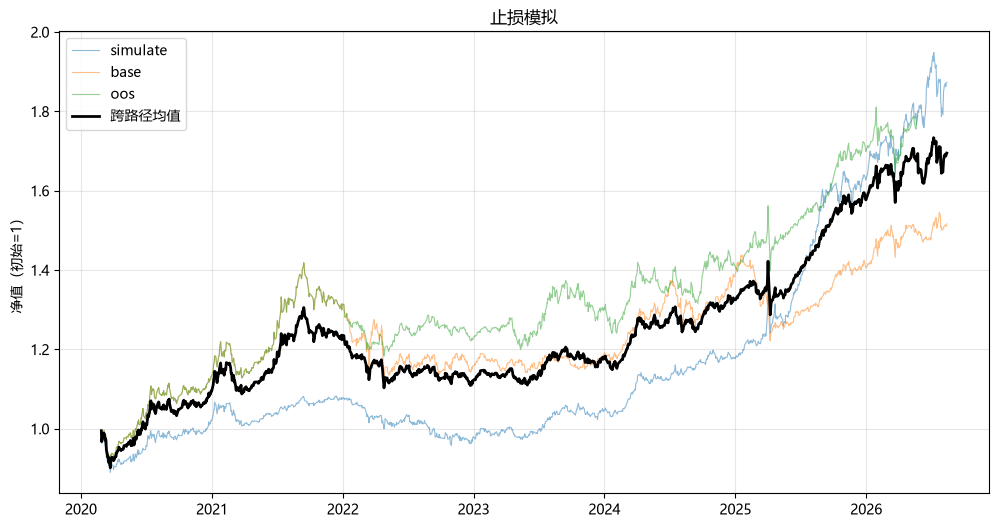

In [70]:
sl_mpts = Population([res['mpt'], base['mpt'], oos_mpt])
plot_paths_curve(sl_mpts, title='止损模拟', labels=['simulate','base', 'oos'])

In [66]:
# 可选传基准供画图：simulate_sl(..., bench=bench_ret)，结果在 res["bench"]
cmp_tbl = summarize_sl(res, base)
cmp_tbl

,年化收益,年化夏普,最大回撤,期末净值,epoch数,止损次数,到期换仓,新搜索(fresh),复用(fold),跳过重搜,交易起点,交易终点
SL模拟,0.0891,0.7555,0.1355,1.6681,8,1,6,8,0,0,2020-02-27,2026-08-14
无止损基线,0.0724,0.6866,0.2058,1.5163,9,4,4,7,2,0,2020-02-27,2026-08-14


In [67]:
print(res["daily"].loc[res["daily"]["trigger"] != ""])  # 仅触发日

                          date  epoch  day_in_epoch       ret  net_global  \
1556 2026-07-28 00:00:00+08:00      6            45 -0.041411     1.63668   

      net_epoch  cum_epoch  dd_epoch  hit_epoch_dd   trigger  
1556   0.993172  -0.006828 -0.102681          True  epoch_dd  


In [ ]:
# 2) 落盘（与既有 log_result 体系一致）
#log_result(cmp_tbl,         section="SL模拟 vs 无止损基线")
#log_result(res["epochs"],   section="SL 模拟 epoch 明细")
#log_result(res["triggers"], section="SL 触发明细")

In [72]:
for pf in res['legs']:
    print(pf.assets)

['160128.SZ' '160140.SZ' '160921.SZ' '167002.SZ' '501300.SH']
['160128.SZ' '161727.SZ' '167002.SZ' '501300.SH' '511220.SH' '511880.SH']
['160515.SZ' '160613.SZ' '160618.SZ' '161010.SZ' '161713.SZ' '165516.SZ'
 '166009.SZ' '167501.SZ' '501022.SH' '501189.SH' '511030.SH' '511880.SH']
['160421.SZ' '511260.SH' '518600.SH']
['161015.SZ' '162719.SZ' '511010.SH' '518800.SH']
['159816.SZ' '161713.SZ' '164701.SZ']
['159611.SZ' '161036.SZ' '161115.SZ' '167002.SZ' '501073.SH' '508058.SH'
 '511010.SH' '512730.SH' '513120.SH' '515880.SH']
['159985.SZ' '161127.SZ' '161716.SZ' '501073.SH']
